# Rain Forecasting with Artificial Neural Network

We'll try to predict rain with ANN.
Let's start !

# What is an artificial neural network?
Artificial neural networks are one of the main tools used in machine learning. As the “neural” part of their name suggests, they are brain-inspired systems which are intended to replicate the way that we humans learn. Neural networks consist of input and output layers, as well as (in most cases) a hidden layer consisting of units that transform the input into something that the output layer can use. They are excellent tools for finding patterns which are far too complex or numerous for a human programmer to extract and teach the machine to recognize.

While neural networks (also called “perceptrons”) have been around since the 1940s, it is only in the last several decades where they have become a major part of artificial intelligence. This is due to the arrival of a technique called “backpropagation,” which allows networks to adjust their hidden layers of neurons in situations where the outcome doesn’t match what the creator is hoping for — like a network designed to recognize dogs, which misidentifies a cat, for example.

Another important advance has been the arrival of deep learning neural networks, in which different layers of a multilayer network extract different features until it can recognize what it is looking for.

![](http://icdn5.digitaltrends.com/image/artificial_neural_network_1-791x388.jpg)

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Any results you write to the current directory are saved as output.

In [4]:
df = pd.read_csv('seattleWeather_1948-2017.csv')

In [5]:
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


# Data Analysis

Checking for *null* values

In [6]:
for column in df:
    print(column)
    print(df[column].isnull().sum().sum())

DATE
0
PRCP
3
TMAX
0
TMIN
0
RAIN
3


There are very few *null* values so we can drop them.

In [7]:
df.dropna(inplace=True)

In [8]:
#plt.figure(figsize=(14,6))
#df['TMAX'].plot()
#plt.xlabel('Days')
#plt.ylabel('Temperature [F]')

In [9]:
#plt.figure(figsize=(12, 7))
#sns.boxplot(x='RAIN',y='TMAX',data=df,palette='winter')

I will make RAIN column numeric before I start with predictions but for analysis it is nicer to see the label names.

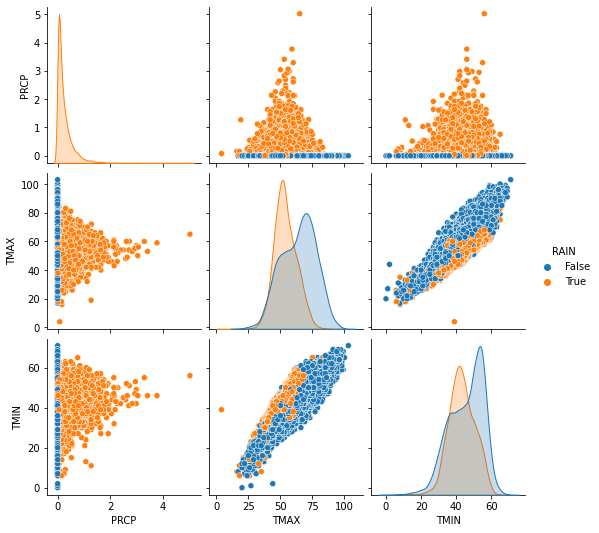

In [10]:
sns.pairplot(df, hue='RAIN')

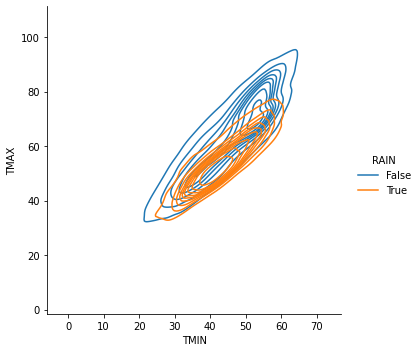

In [11]:
sns.displot(data=df, x='TMIN', y='TMAX', hue='RAIN', kind='kde')

It seems an easy classification problem when you see it. But uncertainty of **not raining** is tricky as you can see on the above.

In [12]:
#df['PRCP'].plot(kind='hist',bins=30,color='orange',figsize= (16,7))

We are going to convert rain column to numeric for ann

In [13]:
rain = pd.get_dummies(df['RAIN'], drop_first=True)
df = df.drop('RAIN', axis=1)
df = pd.concat([df, rain], axis=1)
print(df.shape)
df.head()

(25548, 5)


,DATE,PRCP,TMAX,TMIN,True
0,1948-01-01,0.47,51,42,1
1,1948-01-02,0.59,45,36,1
2,1948-01-03,0.42,45,35,1
3,1948-01-04,0.31,45,34,1
4,1948-01-05,0.17,45,32,1


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import metrics

In [15]:
df.columns = ['DATE', 'PRCP', 'TMAX', 'TMIN', 'RAIN']
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,1
1,1948-01-02,0.59,45,36,1
2,1948-01-03,0.42,45,35,1
3,1948-01-04,0.31,45,34,1
4,1948-01-05,0.17,45,32,1


In [16]:
#df.info()

In [17]:
x = df[['PRCP', 'TMAX', 'TMIN']]
y = df['RAIN']

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [19]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#xtrain = scaler.fit_transform(xtrain)
#xtest = scaler.transform(xtest)

We are going to create ann model.

In [20]:
import keras 
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Dropout

In [21]:
model = Sequential([
    Dense(32, activation='relu', input_dim=3),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
    ])
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                128       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 673
Trainable params: 673
Non-trainable params: 0
_________________________________________________________________


In [22]:
history = model.fit(x_train, y_train, batch_size=10, epochs=20, verbose=1)

Epoch 1/20
1917/1917 [==============================] - 4s 1ms/step - loss: 0.2625 - accuracy: 0.6613
Epoch 2/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.1615 - accuracy: 0.7651
Epoch 3/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.1428 - accuracy: 0.7945
Epoch 4/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.1255 - accuracy: 0.8214
Epoch 5/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.1125 - accuracy: 0.8429
Epoch 6/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.1013 - accuracy: 0.8580
Epoch 7/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.0950 - accuracy: 0.8694
Epoch 8/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.0910 - accuracy: 0.8733
Epoch 9/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.0829 - accuracy: 0.8874
Epoch 10/20
1917/1917 [==============================] - 3s 1ms/step - loss: 0.081

In [23]:
#print(history.history.keys())

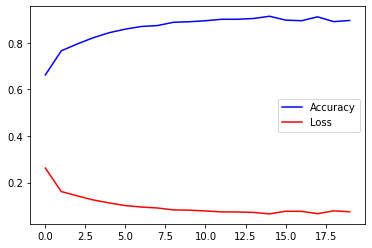

In [24]:
plt.plot(history.history['accuracy'], label='Accuracy', color='blue')
plt.plot(history.history['loss'], label='Loss', color='red')
plt.legend()

In [26]:
prediction_nn = model.predict(x_test)
prediction_nn = [1 if y>=0.5 else 0 for y in prediction_nn]
print(classification_report(y_test, prediction_nn))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3683
           1       1.00      0.98      0.99      2704

    accuracy                           0.99      6387
   macro avg       0.99      0.99      0.99      6387
weighted avg       0.99      0.99      0.99      6387



In [27]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, prediction_nn)
print(cm)

[[3676    7]
 [  43 2661]]
